# AutoEIT — Re-segmentation experiment (4s merge-gap, windowed)

`src/preprocessing/resegment_window.py` re-segments only the last-English-to-last-Spanish window
of each raw recording (`data/raw/audio_files/{version}/segment_window_timestamps.json`, from
`src/preprocessing/build_raw_timestamps.py`), using a **4s VAD merge-gap** instead of the
original full-file segmentation's **2.5s**. Output is at `data/segmented/v2/{version}/`; the
original full-file segmentation was moved to `data/segmented/v1/{version}/` beforehand.

The question this notebook looks at: does the new threshold + windowing produce a more
consistent item count across recordings than the old approach -- specifically, more recordings
landing on exactly 30 items (the expected number of Spanish target sentences), which is the
`hit_miss` criterion used throughout `notebooks/transcription_quality/analyze_transcription_quality*.ipynb`.

For a fair comparison, the "old" segmentation is scoped to the *same* window -- i.e. only the
old-segmentation items between each recording's `min_item_index` and `max_item_index` (exactly
what `data/transcribed/v2`'s `item_count` already reflects), not the full original file (which also
includes the English instructions etc.).

In [1]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import defaultdict
from mutagen.mp3 import MP3

## Config

In [2]:
VERSIONS = ["version_a", "version_b"]
SEGMENTED_V1_ROOT = Path("../../data/segmented/v1")
SEGMENTED_V2_ROOT = Path("../../data/segmented/v2")
RAW_ROOT = Path("../../data/raw/audio_files")
HIT_ITEM_COUNT = 30

## Load new (v2, 4s, windowed) item counts and durations

In [3]:
def load_new_items(version: str) -> pd.DataFrame:
    d = SEGMENTED_V2_ROOT / version
    rows = []
    for f in d.iterdir():
        name = f.name[len("ATTENTION_"):] if f.name.startswith("ATTENTION_") else f.name
        m = re.match(r"^(.+)_item(\d+)\.mp3$", name)
        if not m:
            continue
        recording, idx = m.group(1), int(m.group(2))
        duration = MP3(f).info.length
        rows.append({
            "version": version,
            "recording": recording,
            "item_index": idx,
            "duration": duration,
            "attention": f.name.startswith("ATTENTION_"),
        })
    return pd.DataFrame(rows)


new_items = pd.concat([load_new_items(v) for v in VERSIONS], ignore_index=True)
print(f"{len(new_items)} new (v2) items across {new_items['recording'].nunique()} recordings")

5062 new (v2) items across 184 recordings


## Load old (v1, 2.5s, full-file) items, scoped to the same window

In [4]:
def load_old_items_windowed(version: str) -> pd.DataFrame:
    window_path = RAW_ROOT / version / "segment_window_timestamps.json"
    windows = json.loads(window_path.read_text(encoding="utf-8"))
    d = SEGMENTED_V1_ROOT / version

    rows = []
    for recording, window in windows.items():
        min_idx, max_idx = window["min_item_index"], window["max_item_index"]
        for idx in range(min_idx, max_idx + 1):
            candidates = [d / f"{recording}_item{idx}.mp3", d / f"ATTENTION_{recording}_item{idx}.mp3"]
            for f in candidates:
                if f.exists():
                    duration = MP3(f).info.length
                    rows.append({
                        "version": version,
                        "recording": recording,
                        "item_index": idx,
                        "duration": duration,
                        "attention": f.name.startswith("ATTENTION_"),
                    })
                    break
    return pd.DataFrame(rows)


old_items = pd.concat([load_old_items_windowed(v) for v in VERSIONS], ignore_index=True)
print(f"{len(old_items)} old (v1, windowed) items across {old_items['recording'].nunique()} recordings")

6237 old (v1, windowed) items across 184 recordings


## Item count per recording: old vs. new

In [5]:
old_counts = old_items.groupby(["version", "recording"]).size().rename("old_count")
new_counts = new_items.groupby(["version", "recording"]).size().rename("new_count")
counts = pd.concat([old_counts, new_counts], axis=1).reset_index()
counts["delta"] = counts["new_count"] - counts["old_count"]
print(f"{len(counts)} recordings compared")
counts.head()

184 recordings compared


,version,recording,old_count,new_count,delta
0,version_a,038.069_EITv-2A,30,30,0
1,version_a,038.070_EITv-1A,30,30,0
2,version_a,038.071_EITv2A,30,30,0
3,version_a,038.072_EITv1A,31,29,-2
4,version_a,038.073_EITv2A,30,30,0


In [6]:
hit_rate = pd.DataFrame({
    "old_hit_rate": [(counts["old_count"] == HIT_ITEM_COUNT).mean()],
    "new_hit_rate": [(counts["new_count"] == HIT_ITEM_COUNT).mean()],
    "old_n_hit": [(counts["old_count"] == HIT_ITEM_COUNT).sum()],
    "new_n_hit": [(counts["new_count"] == HIT_ITEM_COUNT).sum()],
    "n_recordings": [len(counts)],
})
hit_rate.round(3)

,old_hit_rate,new_hit_rate,old_n_hit,new_n_hit,n_recordings
0,0.457,0.554,84,102,184


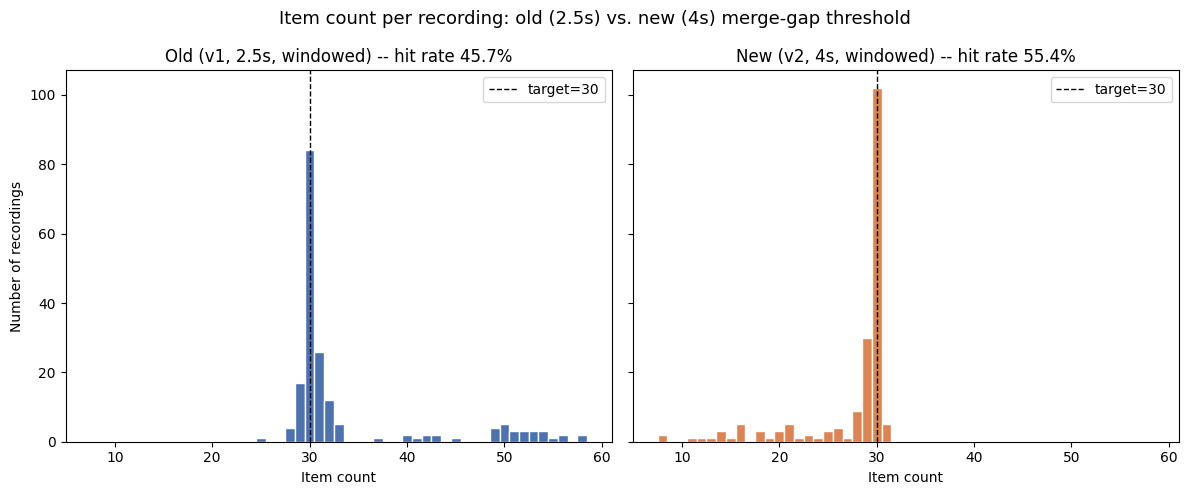

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
bins = np.arange(counts[["old_count", "new_count"]].values.min() - 0.5,
                  counts[["old_count", "new_count"]].values.max() + 1.5, 1)

axes[0].hist(counts["old_count"], bins=bins, color="#4C72B0", edgecolor="white")
axes[0].axvline(HIT_ITEM_COUNT, color="black", linestyle="--", linewidth=1, label=f"target={HIT_ITEM_COUNT}")
axes[0].set_title(f"Old (v1, 2.5s, windowed) -- hit rate {hit_rate['old_hit_rate'][0]:.1%}")
axes[0].set_xlabel("Item count")
axes[0].set_ylabel("Number of recordings")
axes[0].legend()

axes[1].hist(counts["new_count"], bins=bins, color="#DD8452", edgecolor="white")
axes[1].axvline(HIT_ITEM_COUNT, color="black", linestyle="--", linewidth=1, label=f"target={HIT_ITEM_COUNT}")
axes[1].set_title(f"New (v2, 4s, windowed) -- hit rate {hit_rate['new_hit_rate'][0]:.1%}")
axes[1].set_xlabel("Item count")
axes[1].legend()

fig.suptitle("Item count per recording: old (2.5s) vs. new (4s) merge-gap threshold", fontsize=13)
fig.tight_layout()
plt.savefig("../plots/resegment_item_count_old_vs_new.png", dpi=150)
plt.show()

## Per-recording delta (new_count - old_count)

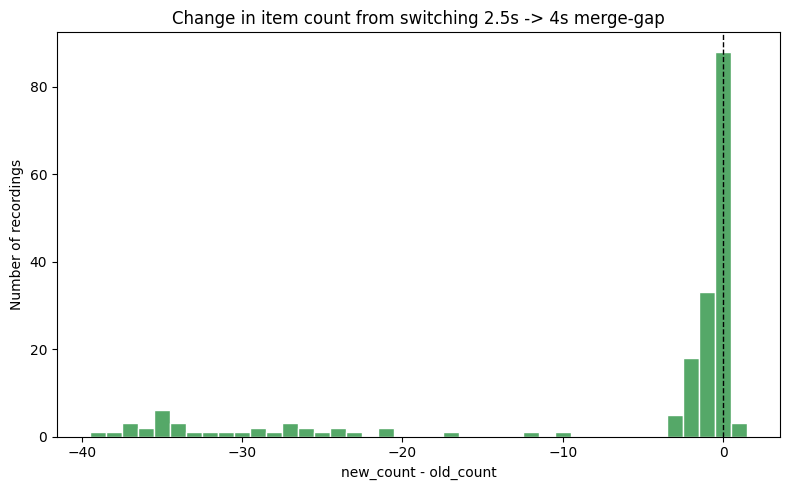

count    184.00
mean      -6.39
std       12.11
min      -39.00
25%       -2.00
50%       -1.00
75%        0.00
max        1.00
Name: delta, dtype: float64


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(counts["delta"], bins=np.arange(counts["delta"].min() - 0.5, counts["delta"].max() + 1.5, 1),
        color="#55A868", edgecolor="white")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("new_count - old_count")
ax.set_ylabel("Number of recordings")
ax.set_title("Change in item count from switching 2.5s -> 4s merge-gap")
fig.tight_layout()
plt.savefig("../plots/resegment_count_delta.png", dpi=150)
plt.show()

print(counts["delta"].describe().round(2))

## Item duration: old vs. new

In [9]:
print("Old (v1, windowed):")
display(old_items["duration"].describe(percentiles=[.5, .9]).round(2))
print(f"ATTENTION_ (>10s) rate: {old_items['attention'].mean():.1%}")
print()
print("New (v2, 4s, windowed):")
display(new_items["duration"].describe(percentiles=[.5, .9]).round(2))
print(f"ATTENTION_ (>10s) rate: {new_items['attention'].mean():.1%}")

Old (v1, windowed):


count    6237.00
mean        5.77
std         3.21
min         1.83
50%         5.15
90%         7.94
max        62.93
Name: duration, dtype: float64

ATTENTION_ (>10s) rate: 2.0%

New (v2, 4s, windowed):


count    5062.00
mean        7.30
std        10.46
min         1.44
50%         5.43
90%        10.24
max       189.34
Name: duration, dtype: float64

ATTENTION_ (>10s) rate: 5.0%


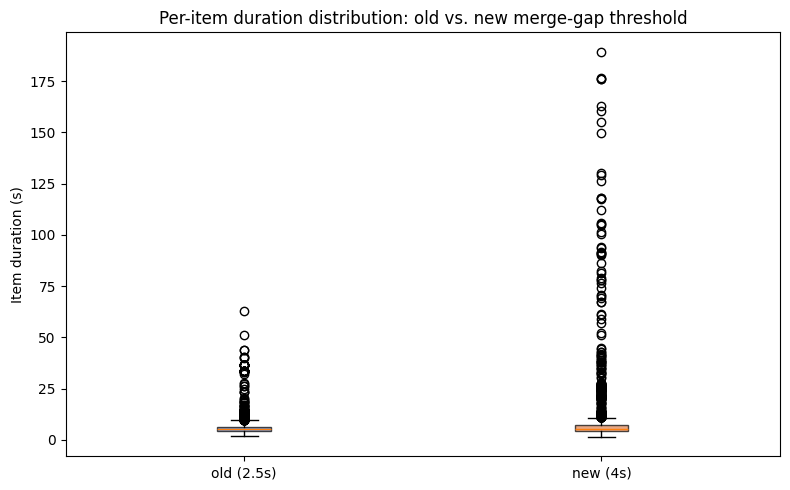

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
bplot = ax.boxplot([old_items["duration"], new_items["duration"]],
                    tick_labels=["old (2.5s)", "new (4s)"], patch_artist=True, showfliers=True)
for patch, color in zip(bplot["boxes"], ["#4C72B0", "#DD8452"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel("Item duration (s)")
ax.set_title("Per-item duration distribution: old vs. new merge-gap threshold")
fig.tight_layout()
plt.savefig("../plots/resegment_duration_distribution.png", dpi=150)
plt.show()

## Takeaway

Compares strictly within the same audio window, so any difference is attributable to the
merge-gap threshold (2.5s vs. 4s) alone, not to the windowing/cropping change (both segmentations
share that).

**Result: the 4s threshold raises the hit rate (45.7% -> 55.4%, 84 -> 102 of 184 recordings) but
also raises the over-merge rate (ATTENTION_/>10s items: 2.0% -> 5.0%, max single-item duration
6.9s -> 189.3s).** So it isn't a clean win -- most recordings lose a small number of items
(median delta -1, meaning 4s merges two adjacent items together more often than it should), which
happens to correct several 31/32-item "miss" recordings down to exactly 30 (net hit-rate gain),
but a handful of recordings over-merge dramatically (min delta -39 on one recording, and that
189s single-item outlier), i.e. 4s is too aggressive for pauses that were never meant to bridge
two different sentences.

Next step: look at the delta outliers directly (worst few recordings by `abs(delta)`) to see if
they share a cause (e.g. a participant who paused unusually long mid-sentence), and consider a
threshold between 2.5s and 4s, or a per-recording adaptive threshold, rather than one fixed value
for everyone.